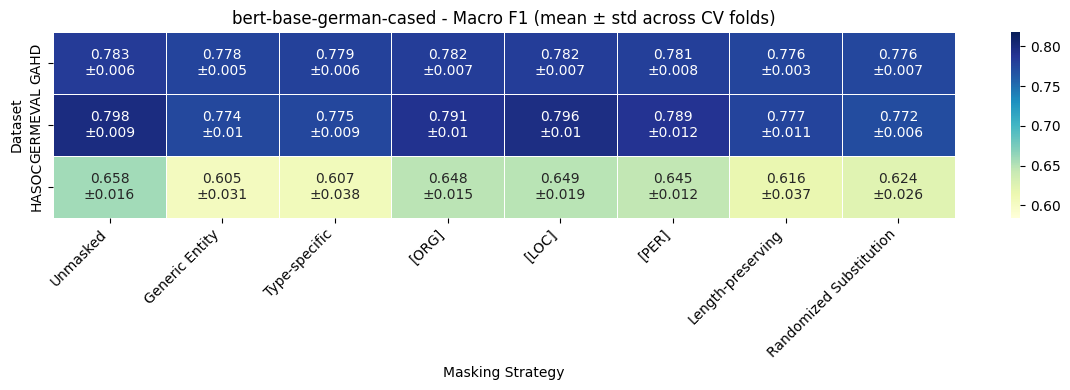

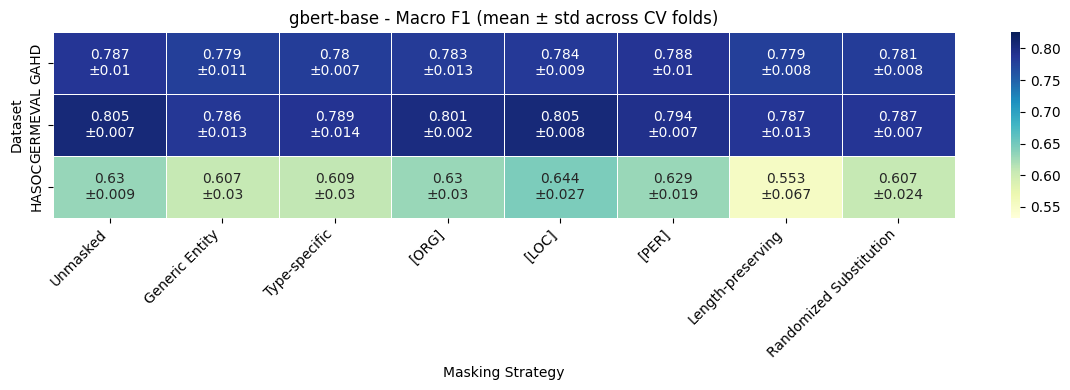

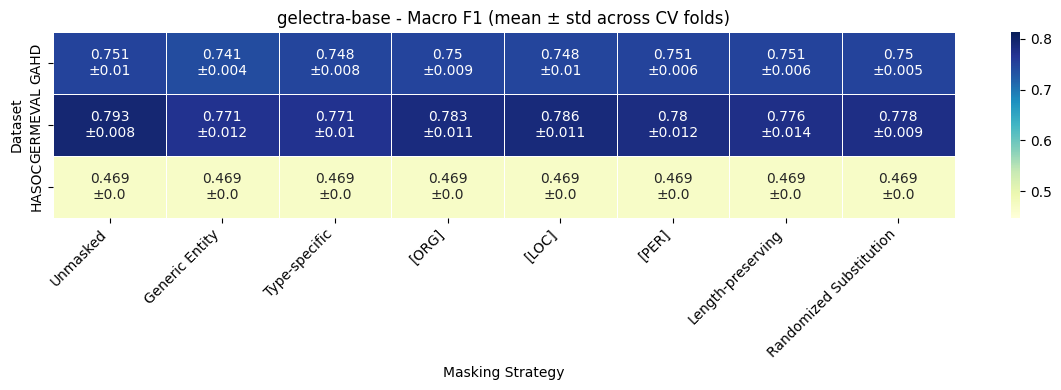

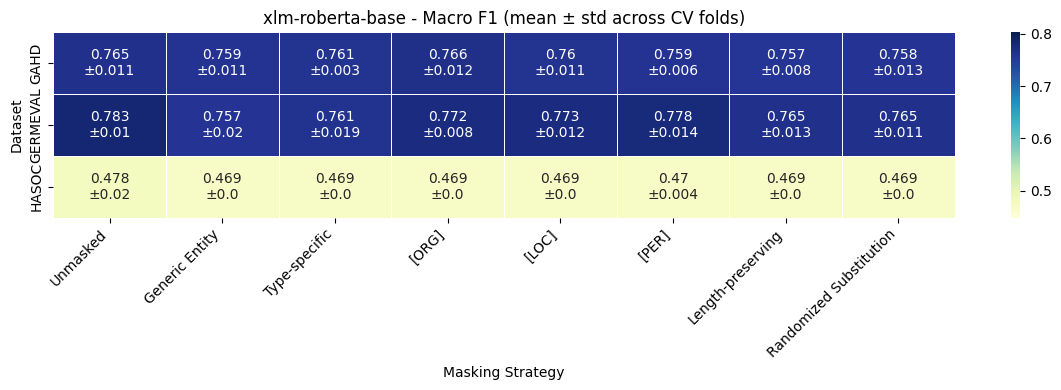

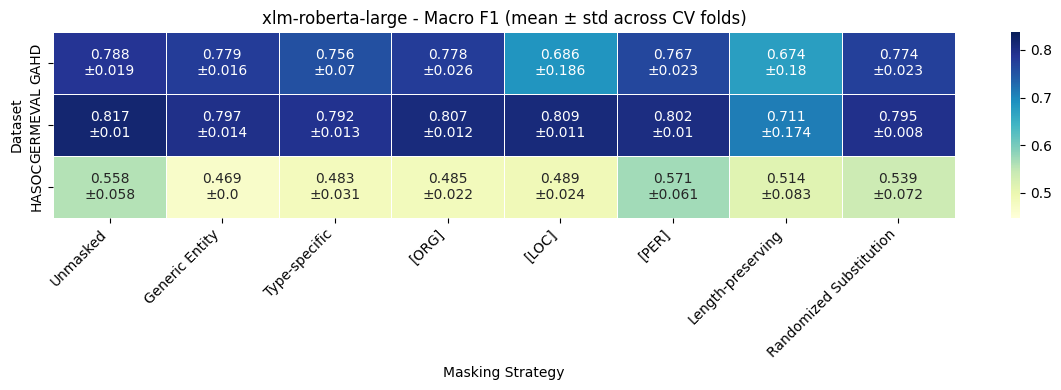


Average F1 per strategy:

Strategy
Unmasked                   0.710805
[PER]                      0.704859
[ORG]                      0.700918
[LOC]                      0.696510
Randomized Substitution    0.696151
Type-specific              0.689965
Generic Entity             0.689255
Length-preserving          0.678225
Name: F1_macro, dtype: float64


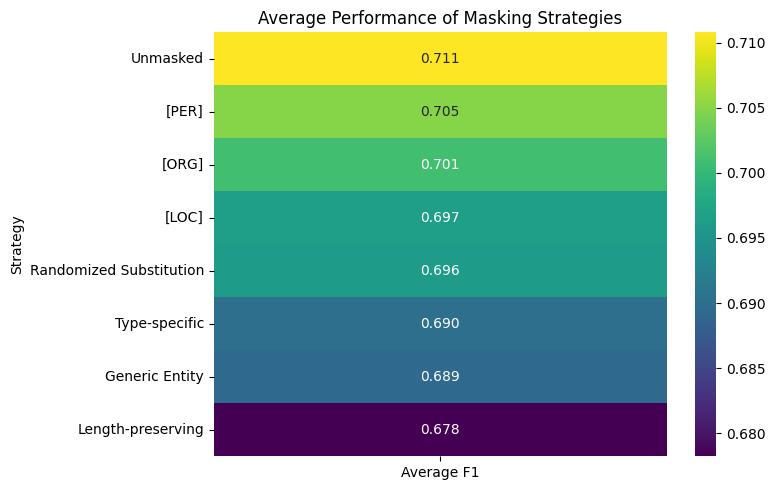

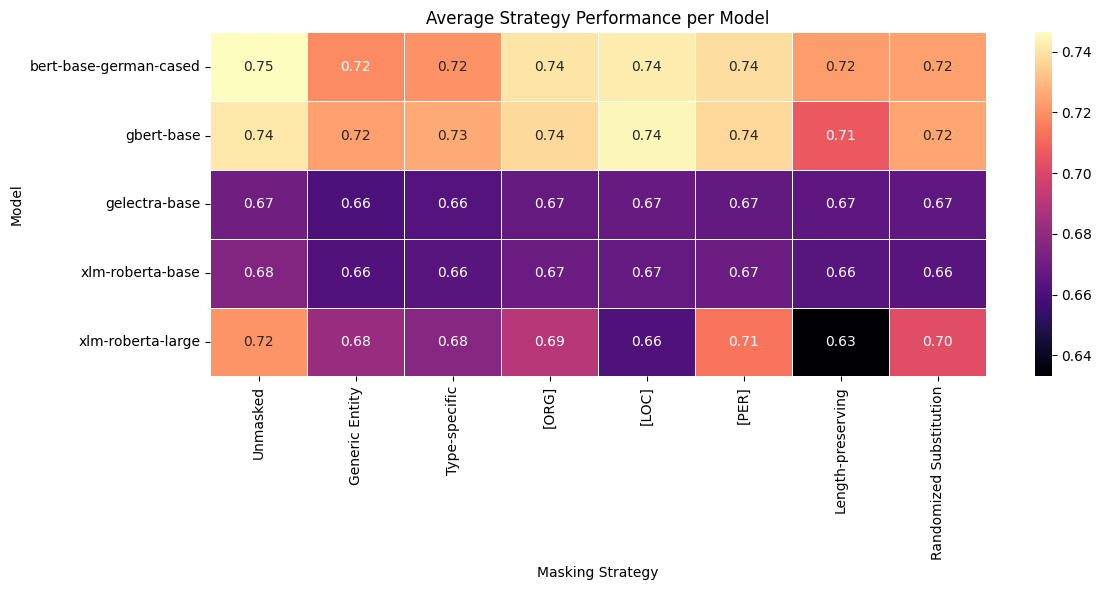

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA
# -----------------------------
import csv, io
import pandas as pd

with open('Results.csv', encoding='utf-8', newline='') as f:
    raw = f.read()

lines = [l for l in raw.split('\r\n') if l != '']
header, data_lines = lines[0], lines[1:]

# strip outer quote wrapper + undo one level of doubled quotes
unwrapped = [l[1:-1].replace('""', '"') for l in data_lines]
text = header + '\n' + '\n'.join(unwrapped)

df = pd.read_csv(io.StringIO(text))

new_order = [
    "Unmasked",
    "Placeholder",
    "Type-specific",
    "[ORG]",
    "[LOC]",
    "[PER]",
    "Length",
    "Random",
]

# Optional prettier labels for plots
pretty_labels = {
    "Unmasked": "Unmasked",
    "Placeholder": "Generic Entity",
    "Type-specific": "Type-specific",
    "[ORG]": "[ORG]",
    "[LOC]": "[LOC]",
    "[PER]": "[PER]",
    "Length": "Length-preserving",
    "Random": "Randomized Substitution",
}

# Map raw CSV strategy codes -> short strategy keys used above
strategy_map = {
    "PER_ORG_LOC_GENERIC_ENTITY": "Placeholder",
    "PER_ORG_LOC_TYPED": "Type-specific",
    "ORG_ONLY": "[ORG]",
    "LOC_ONLY": "[LOC]",
    "PER_ONLY": "[PER]",
    "X_LENGTH": "Length",
    "RANDOM_SUBSTITUTION": "Random",
    # If/when an unmasked baseline is added to the CSV, map its code here, e.g.:
    "UNMASKED": "Unmasked",
}

df["Strategy"] = df["Strategy"].map(strategy_map).fillna(df["Strategy"])

# Only keep strategies that are both mapped and actually present in the data,
# in the requested order
strategies = [s for s in new_order if s in df["Strategy"].unique()]
missing = [s for s in new_order if s not in strategies]
if missing:
    print(f"Note: no data found for strategies: {missing} (skipped)")

# Optional: nicer model display names
model_name_map = {
    "BERT_GERMAN": "bert-base-german-cased",
    "GBERT": "gbert-base",
    "GELECTRA_BASE": "gelectra-base",
    "XLM_ROBERTA": "xlm-roberta-base",
    "XLM_ROBERTA_LARGE": "xlm-roberta-large",
}
df["Model"] = df["Model"].map(model_name_map).fillna(df["Model"])

# -----------------------------
# AGGREGATE ACROSS CV FOLDS
# -----------------------------

agg = (
    df.groupby(["Model", "Dataset", "Strategy"])["F1_macro"]
    .agg(["mean", "std"])
    .reset_index()
)

# -----------------------------
# HEATMAPS MODEL-WISE (mean F1, annotated with mean ± std)
# -----------------------------

for model_name in agg["Model"].unique():

    model_agg = agg[agg["Model"] == model_name]

    mean_df = model_agg.pivot(index="Dataset", columns="Strategy", values="mean")
    std_df = model_agg.pivot(index="Dataset", columns="Strategy", values="std")

    # reorder columns per new_order, use pretty labels
    mean_df = mean_df[strategies].rename(columns=pretty_labels)
    std_df = std_df[strategies].rename(columns=pretty_labels)

    annot = mean_df.round(3).astype(str) + "\n±" + std_df.round(3).astype(str)

    plt.figure(figsize=(12, 4))

    sns.heatmap(
        mean_df,
        annot=annot,
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        vmin=mean_df.values.min() - 0.02,
        vmax=mean_df.values.max() + 0.02,
    )

    plt.title(f"{model_name} - Macro F1 (mean ± std across CV folds)")
    plt.xlabel("Masking Strategy")
    plt.ylabel("Dataset")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(f"{model_name}_heatmap_masked.png", dpi=1200,bbox_inches="tight")
    plt.show()

# -----------------------------
# STRATEGY-WISE AVERAGE (mean across all models/datasets/folds)
# -----------------------------

strategy_avg = (
    df[df["Strategy"].isin(strategies)]
    .groupby("Strategy")["F1_macro"]
    .mean()
    .reindex(strategies)
    .rename(index=pretty_labels)
    .sort_values(ascending=False)
)

print("\nAverage F1 per strategy:\n")
print(strategy_avg)

plt.figure(figsize=(8, 5))

sns.heatmap(
    strategy_avg.to_frame(name="Average F1"),
    annot=True,
    cmap="viridis",
    fmt=".3f",
)

plt.title("Average Performance of Masking Strategies")
plt.tight_layout()

plt.savefig("average_performance_of_masking_strategies.png", dpi=1200, bbox_inches="tight")
plt.show()

# -----------------------------
# MODEL COMPARISON (mean F1 per model x strategy, averaged across datasets/folds)
# -----------------------------

model_avg = (
    df[df["Strategy"].isin(strategies)]
    .groupby(["Model", "Strategy"])["F1_macro"]
    .mean()
    .unstack("Strategy")[strategies]
    .rename(columns=pretty_labels)
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    model_avg,
    annot=True,
    cmap="magma",
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Average Strategy Performance per Model")
plt.xlabel("Masking Strategy")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig("average_performance_of_masking_strategies.png", dpi=1200, bbox_inches="tight")
plt.show()


